## Notebook 02 - Eigenvector Centrality per team
Núria Pascual Salas

**Content:** Computes match-level Eigenvector Centrality (mean EC across the
players of each passing network) and relates playing style, connectivity, and
results through three within-team correlations: r(SF, EC), r(EC, Points), and
r(SF, Points).

**Outputs:**
- outputs/figures/sfec_scatter_league.png

**Used in:** Chapter 3, Section 3.3 (Eigenvector Centrality).

In [ ]:
from utils import *
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from scipy import stats

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'


### 1. Load data

In [11]:
# Load all 20 LaLiga teams
all_teams = {}
match_generator = stream_matches_from_zip(zip_path, folder_laliga, "_events.json")

for m_id, events in match_generator:
    for e in events:
        if 'team' in e:
            tid = e['team']['id']
            tname = e['team']['name']
            if tid not in all_teams:
                all_teams[tid] = tname
    if len(all_teams) >= 20:
        break

for tid in sorted(all_teams.keys()):
    print(f"ID: {tid} | Team: {all_teams[tid]}")

ID: 206 | Team: Deportivo Alavés
ID: 207 | Team: Valencia
ID: 208 | Team: Las Palmas
ID: 209 | Team: Celta Vigo
ID: 210 | Team: Real Sociedad
ID: 211 | Team: Girona
ID: 212 | Team: Atlético Madrid
ID: 213 | Team: Sevilla
ID: 215 | Team: Athletic Club
ID: 216 | Team: Getafe
ID: 217 | Team: Barcelona
ID: 218 | Team: Real Betis
ID: 220 | Team: Real Madrid
ID: 222 | Team: Villarreal
ID: 360 | Team: Rayo Vallecano
ID: 403 | Team: Almería
ID: 422 | Team: Osasuna
ID: 552 | Team: Cádiz
ID: 1043 | Team: Mallorca
ID: 1049 | Team: Granada


### 2. Plotting function

In [12]:
def plot_sf_ec(df, team_name):
    """3-panel plot: SF vs EC, EC vs Points, SF vs Points."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'SF vs EC Analysis - {team_name}', fontsize=15)

    color_map = {'win': 'seagreen', 'draw': 'grey', 'lost': 'red'}
    colors = df['result'].map(color_map)

    # Panel 1: SF vs EC
    axes[0].scatter(df['sf'], df['ec'], c=colors, s=100, alpha=0.7,
                    edgecolors='black', linewidths=0.5)
    r, p = stats.pearsonr(df['sf'], df['ec'])
    axes[0].set_title(f'SF vs EC\nr={r:.2f}, p={p:.3f}')
    axes[0].set_xlabel('Switching Factor (SF)')
    axes[0].set_ylabel('Avg Eigenvector Centrality (EC)')
    axes[0].grid(alpha=0.3)
    for res, c in color_map.items():
        axes[0].scatter([], [], color=c, label=res, s=80)
    axes[0].legend()

    # Panel 2: EC vs Points
    r2, p2 = stats.pearsonr(df['ec'], df['points'])
    axes[1].scatter(df['ec'], df['points'], c=colors, s=100, alpha=0.7,
                    edgecolors='black', linewidths=0.5)
    m, b = np.polyfit(df['ec'], df['points'], 1)
    x_line = np.linspace(df['ec'].min(), df['ec'].max(), 100)
    axes[1].plot(x_line, m * x_line + b, color='navy', linewidth=2, linestyle='--')
    axes[1].set_title(f'EC vs Points\nr={r2:.2f}, p={p2:.3f}')
    axes[1].set_xlabel('Avg Eigenvector Centrality (EC)')
    axes[1].set_ylabel('Points')
    axes[1].grid(alpha=0.3)

    # Panel 3: SF vs Points
    r3, p3 = stats.pearsonr(df['sf'], df['points'])
    axes[2].scatter(df['sf'], df['points'], c=colors, s=100, alpha=0.7,
                    edgecolors='black', linewidths=0.5)
    m3, b3 = np.polyfit(df['sf'], df['points'], 1)
    x3 = np.linspace(df['sf'].min(), df['sf'].max(), 100)
    axes[2].plot(x3, m3 * x3 + b3, color='red', linewidth=2, linestyle='--')
    axes[2].set_title(f'SF vs Points\nr={r3:.2f}, p={p3:.3f}')
    axes[2].set_xlabel('Switching Factor (SF)')
    axes[2].set_ylabel('Points')
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return r, r2, r3

### 3. League table: SF–EC–Points correlations per team

In [13]:
league_ec_results = []

for team_id, team_name in all_teams.items():
    df_team = analisi_sf_ec_temporada(team_id, team_name, zip_path, folder_laliga)
    if len(df_team) < 10:
        continue
    r_sf_ec, _ = stats.pearsonr(df_team['sf'], df_team['ec'])
    r_ec_pts, _ = stats.pearsonr(df_team['ec'], df_team['points'])
    r_sf_pts, _ = stats.pearsonr(df_team['sf'], df_team['points'])
    league_ec_results.append({
        'Team': team_name,
        'r(SF,EC)':     round(r_sf_ec, 3),
        'r(EC,Points)': round(r_ec_pts, 3),
        'r(SF,Points)': round(r_sf_pts, 3),
    })

df_league_ec = pd.DataFrame(league_ec_results).sort_values('r(EC,Points)', ascending=False)
print(df_league_ec.to_string(index=False))

            Team  r(SF,EC)  r(EC,Points)  r(SF,Points)
        Mallorca    -0.002         0.152         0.256
          Getafe     0.314         0.134         0.085
Deportivo Alavés    -0.047         0.106         0.442
   Real Sociedad     0.259         0.101         0.203
         Almería     0.159         0.072         0.120
         Osasuna    -0.036         0.068         0.111
  Rayo Vallecano     0.047         0.059         0.286
      Las Palmas     0.277        -0.027        -0.006
 Atlético Madrid     0.523        -0.030        -0.043
     Real Madrid     0.277        -0.053        -0.021
        Valencia     0.242        -0.063         0.040
           Cádiz     0.312        -0.121         0.119
          Girona     0.194        -0.146         0.193
      Real Betis     0.220        -0.156        -0.148
      Celta Vigo     0.212        -0.240        -0.158
      Villarreal     0.012        -0.250         0.190
   Athletic Club     0.049        -0.289         0.396
         G

### 4. Scatter: r(SF, Points) vs r(EC, Points)

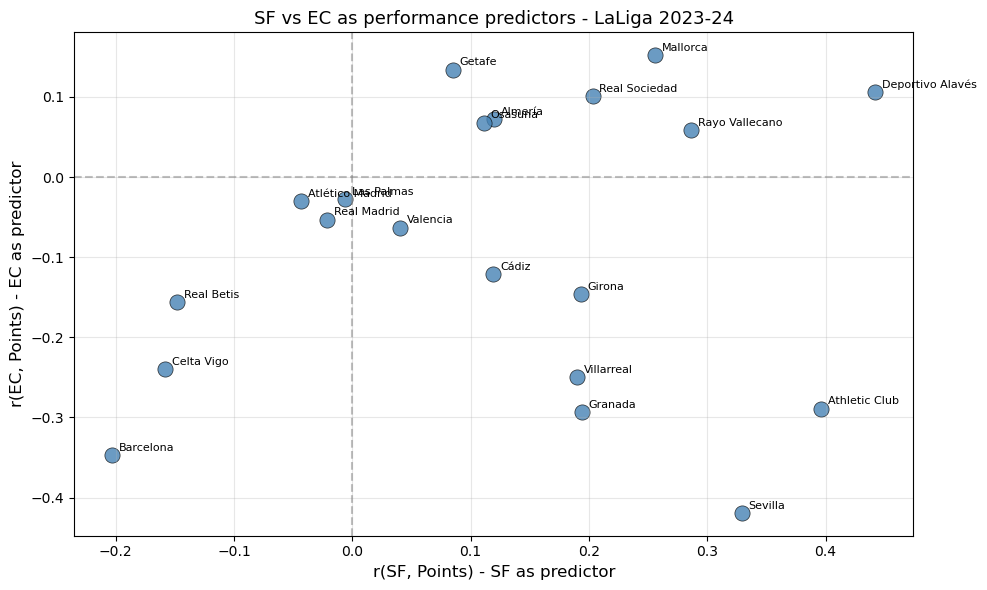

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df_league_ec['r(SF,Points)'],
    df_league_ec['r(EC,Points)'],
    s=120, edgecolors='black', linewidths=0.5, alpha=0.8, color='steelblue'
)
for _, row in df_league_ec.iterrows():
    plt.annotate(row['Team'], (row['r(SF,Points)'], row['r(EC,Points)']),
                 fontsize=8, textcoords='offset points', xytext=(5, 3))

plt.axhline(0, color='grey', linestyle='--', alpha=0.5)
plt.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.xlabel('r(SF, Points) - SF as predictor', fontsize=12)
plt.ylabel('r(EC, Points) - EC as predictor', fontsize=12)
plt.title('SF vs EC as performance predictors - LaLiga 2023-24', fontsize=13)
plt.savefig(f'{FIGURES_DIR}/sf_vs_ec_scatter.png',
            dpi=130, bbox_inches='tight')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()